this notebook only used to generate plots

In [1]:



import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from toy_thesis_minimal import simulate_toy_finrep, ToyConfig, DATE_COL
from inject_structural import inject_peer_anomaly
from feature_matrix import build_peer_ratio_matrix, compute_total_asset_ratios
from preprocessing import filter_missingness, RobustIQRScaler
from models.vae import VAEDetector
from eval.metrics_clean import make_binary_labels, evaluate_scores

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
import warnings
warnings.filterwarnings("ignore")

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

def plot_1d_experiment_results(df, x_col="n_features"):
    """Plots ROC-AUC and Precision@k as line plots for a single varying parameter."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. ROC-AUC Plot
    sns.lineplot(
        data=df, x=x_col, y="roc_auc", 
        marker="o", markersize=8, linewidth=2, 
        ax=axes[0], color="navy"
    )
    axes[0].set_title(f"VAE Performance: ROC-AUC vs {x_col}", fontweight="bold")
    axes[0].set_xlabel("Number of Features (n_features)")
    axes[0].set_ylabel("ROC-AUC")
    axes[0].set_ylim(0.4, 1.05) # Typical AUC bounds
    
    # 2. Precision@k Plot
    sns.lineplot(
        data=df, x=x_col, y="precision_at_k", 
        marker="s", markersize=8, linewidth=2, 
        ax=axes[1], color="darkred"
    )
    axes[1].set_title(f"VAE Performance: Precision@k vs {x_col}", fontweight="bold")
    axes[1].set_xlabel("Number of Features (n_features)")
    axes[1].set_ylabel("Precision at k")
    axes[1].set_ylim(-0.05, 1.05)
    
    plt.tight_layout()
    plt.savefig(f"1d_performance_{x_col}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

def plot_2d_heatmap(df, x_col="n_features", y_col="severity", metric="roc_auc"):
    """
    Plots 2D heatmap. 
    NOTE: need to run an experiment varying BOTH x_col and y_col to use.
    """
    # Check if we actually have multiple unique values for the y_col
    if df[y_col].nunique() < 2:
        print(f"Skipping heatmap: Only one unique value found '{y_col}'.")
        return
        
    plt.figure(figsize=(8, 6))
    
    # Pivot the dataframe 
    pivot_table = df.pivot(index=y_col, columns=x_col, values=metric)
    
    sns.heatmap(
        pivot_table, 
        annot=True,          
        fmt=".3f",           
        cmap="viridis",      
        cbar_kws={'label': metric.upper()}
    )
    
    plt.title(f"Heatmap: {metric.upper()} by {x_col} and {y_col}", fontweight="bold", pad=15)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    
    # Invert Y axis so lower severity is at the bottom
    plt.gca().invert_yaxis() 
    
    plt.tight_layout()
    plt.savefig(f"heatmap_{metric}_{x_col}_vs_{y_col}.pdf", format="pdf", bbox_inches="tight")
    plt.show()



In [3]:
def plot_roc_vs_precision(df, hue_col="n_features"):
    """
    Plots ROC-AUC vs Precision@k to visualize the performance trade-off space.
    The points are colored based on the varying parameter (e.g., n_features).
    """
    plt.figure(figsize=(8, 6))
    
    # 
    # Sort by the varying parameter
    df_sorted = df.sort_values(by=hue_col)
    sns.lineplot(
        data=df_sorted, x="roc_auc", y="precision_at_k", 
        color="gray", alpha=0.4, sort=False, linewidth=1.5
    )
    
    # main scatter points
    scatter = sns.scatterplot(
        data=df_sorted, x="roc_auc", y="precision_at_k", 
        hue=hue_col, s=150, palette="viridis", edgecolor="black", 
        zorder=3 # Ensures points are drawn on top of the line
    )
    
    plt.title(f"Trade-off Space: Precision@k vs. ROC-AUC", fontweight="bold", pad=15)
    plt.xlabel("ROC-AUC (Global Ranking Quality)")
    plt.ylabel("Precision at k (Top-k Anomaly Detection)")
    
    plt.xlim(0.4, 1.05)
    plt.ylim(-0.05, 1.05)
    
    plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig(f"scatter_roc_vs_precision_by_{hue_col}.pdf", format="pdf", bbox_inches="tight")
    plt.show()


We first define the single varying parameter n_factor

In [4]:
import itertools
import pandas as pd


n_factors_list = [5, 10, 15, 20, 30]

# 2. Define fixed parameters for the experiment
fixed_params = {
    "n_features": 500,         # Fixed feature dimension
    "latent_dim": 10,          # Fixed VAE Bottleneck size
    "beta": 0.1,               # Weight of the KL-Divergence penalty
    "contamination": 0.1,      # Low vs. High contamination
    "severity": 0.1            # Mild vs. Severe structural breaks
}

target_q = 202312
results = []
fixed_budget_k = 10  # Fixing the supervisory budget to 10 banks

print(f"Running {len(n_factors_list)} VAE experimental setups exploring true data complexity (n_factors)...")

for i, f in enumerate(n_factors_list):
    # Extract fixed parameters 
    n_feat = fixed_params["n_features"]
    l_dim = fixed_params["latent_dim"]
    beta_val = fixed_params["beta"]
    contam = fixed_params["contamination"]
    sev = fixed_params["severity"]
    
    print(f"\n--- Starting Iteration {i+1}/{len(n_factors_list)}: n_factors = {f} ---")
    
    # 1. Generate Full Clean Panel
    cfg = ToyConfig(n_banks=100, n_features=n_feat, n_factors=f, random_state=i)
    clean_df, value_cols = simulate_toy_finrep(cfg)
    
    # 2. Inject Anomalies into Target Quarter
    injection = inject_peer_anomaly(
        clean_df,
        target_quarter=target_q,
        cols=value_cols,
        row_fraction=contam,
        feature_fraction=sev,
        random_state=i
    )
    

    # History:
    historical_df = clean_df[clean_df[DATE_COL] < target_q].copy()
    fm_train = compute_total_asset_ratios(historical_df, value_columns=value_cols)
    
    # Target: The contaminated quarter
    corrupted_df = injection["data"]
    fm_test = build_peer_ratio_matrix(corrupted_df, quarter=target_q, value_columns=value_cols)
    
    # 4. Fit Scaler
    scaler = RobustIQRScaler(imputation="median")
    X_train_scaled = scaler.fit_transform(fm_train.X)
    X_test_scaled = scaler.transform(fm_test.X)
    
    # 5. Train VAE on Nominal History
    vae = VAEDetector(
        latent_dim=l_dim, 
        hidden_dim=32, 
        epochs=500,          
        beta=beta_val, 
        random_state=i
    )
    vae.fit(X_train_scaled)
    
    # 6. Score Target Quarter
    scores = vae.score_samples(X_test_scaled)
    
    # 7. Evaluate 
    y_true = make_binary_labels(fm_test.metadata, injection["row_labels"], outlier_type="peer")
    metrics_df = evaluate_scores(y_true, scores)
    
    res_dict = fixed_params.copy()
    res_dict["n_factors"] = f
    res_dict["roc_auc"] = metrics_df["roc_auc"].iloc[0]
    res_dict["precision_at_k"] = metrics_df["precision_at_k"].iloc[0]
    res_dict["recall_at_k"] = metrics_df["recall_at_k"].iloc[0]
    
    results.append(res_dict)

results_df = pd.DataFrame(results)
print("\nVAE Data Complexity (n_factors) Experiment complete!")
display(results_df)

Running 5 VAE experimental setups exploring true data complexity (n_factors)...

--- Starting Iteration 1/5: n_factors = 5 ---

--- Starting Iteration 2/5: n_factors = 10 ---

--- Starting Iteration 3/5: n_factors = 15 ---

--- Starting Iteration 4/5: n_factors = 20 ---

--- Starting Iteration 5/5: n_factors = 30 ---

VAE Data Complexity (n_factors) Experiment complete!


,n_features,latent_dim,beta,contamination,severity,n_factors,roc_auc,precision_at_k,recall_at_k
0,500,10,0.1,0.1,0.1,5,0.987778,0.8,0.8
1,500,10,0.1,0.1,0.1,10,0.977778,0.8,0.8
2,500,10,0.1,0.1,0.1,15,0.765556,0.1,0.1
3,500,10,0.1,0.1,0.1,20,0.701111,0.1,0.1
4,500,10,0.1,0.1,0.1,30,0.710000,0.0,0.0


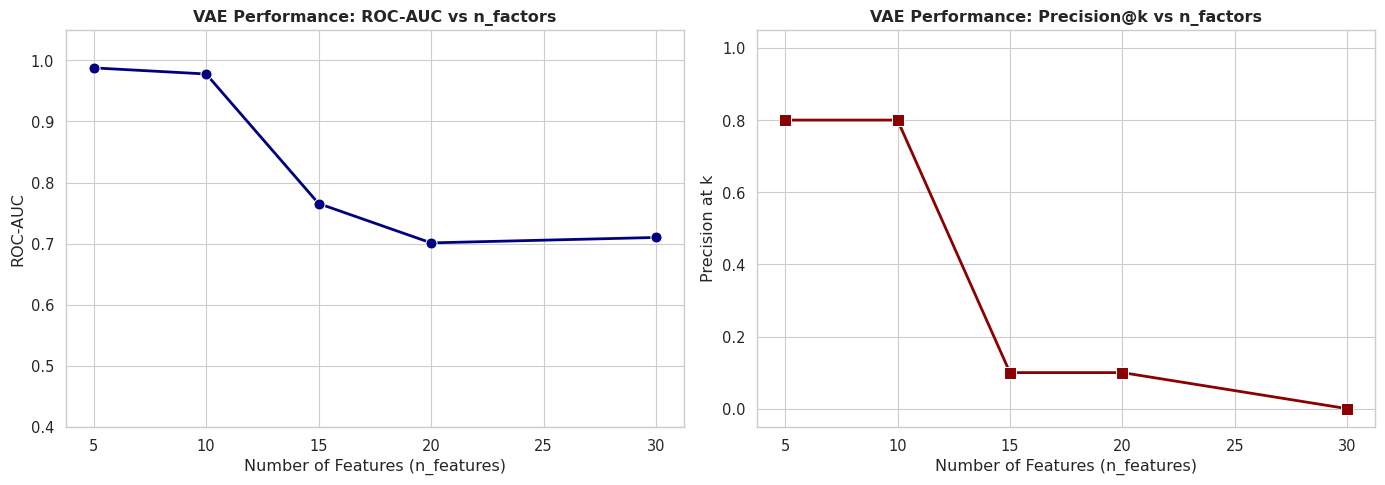

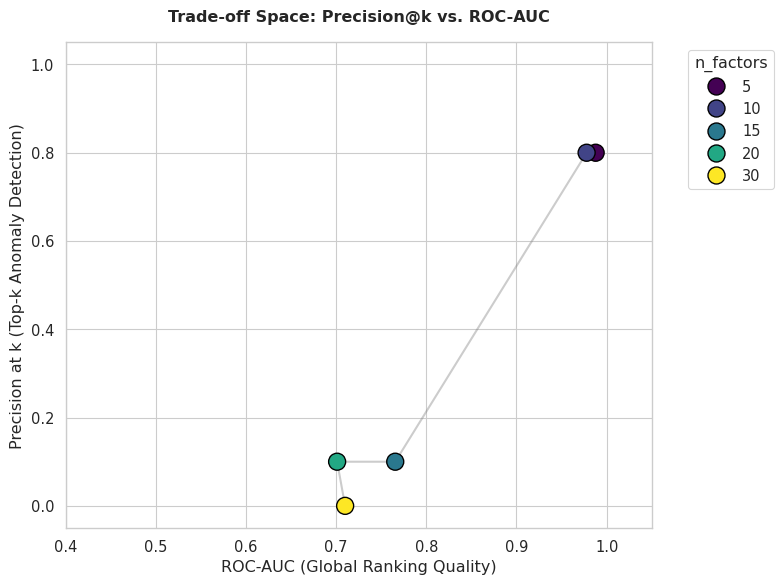

Skipping heatmap: Only one unique value found 'severity'.


In [ ]:
# 1. Plot the 1D results for true data complexity experiment
plot_1d_experiment_results(results_df, x_col="n_factors")

# 2. Plot trade-off scatter plot
if 'plot_roc_vs_precision' in globals():
    plot_roc_vs_precision(results_df, hue_col="n_factors")


find beta

In [ ]:
import itertools
import pandas as pd

beta_list = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]

# 2. Define fixed parameters
fixed_params = {
    "n_features": 500,         # Fixed feature dimension
    "n_factors": 10,           # True complexity of the data
    "latent_dim": 10,          # Fixed VAE Bottleneck size
    "contamination": 0.1,      # Low vs. High contamination
    "severity": 0.1            # Mild vs. Severe structural breaks
}

target_q = 202312
results = []
fixed_budget_k = 10  # useless

print(f"Running {len(beta_list)} VAE experimental setups exploring the KL-Divergence penalty (beta)...")

for i, beta_val in enumerate(beta_list):
    # Extract
    n_feat = fixed_params["n_features"]
    f = fixed_params["n_factors"]
    l_dim = fixed_params["latent_dim"]
    contam = fixed_params["contamination"]
    sev = fixed_params["severity"]
    
    print(f"\n--- Starting Iteration {i+1}/{len(beta_list)}: beta = {beta_val} ---")
    
    # 1. Generate Full Clean Panel
    cfg = ToyConfig(n_banks=100, n_features=n_feat, n_factors=f, random_state=i)
    clean_df, value_cols = simulate_toy_finrep(cfg)
    
    # 2. Inject Anomalies  into  Target Quarter
    injection = inject_peer_anomaly(
        clean_df,
        target_quarter=target_q,
        cols=value_cols,
        row_fraction=contam,
        feature_fraction=sev,
        random_state=i
    )
    

    # History: 
    historical_df = clean_df[clean_df[DATE_COL] < target_q].copy()
    fm_train = compute_total_asset_ratios(historical_df, value_columns=value_cols)
    
    # Target: contaminated quarter
    corrupted_df = injection["data"]
    fm_test = build_peer_ratio_matrix(corrupted_df, quarter=target_q, value_columns=value_cols)
    
    # 4. Fit Scaler on History 
    scaler = RobustIQRScaler(imputation="median")
    X_train_scaled = scaler.fit_transform(fm_train.X)
    X_test_scaled = scaler.transform(fm_test.X)
    
    # 5. Train VAE on Nominal History
    vae = VAEDetector(
        latent_dim=l_dim, 
        hidden_dim=32, 
        epochs=500,          
        beta=beta_val,       #
        random_state=i
    )
    vae.fit(X_train_scaled)
    
    # 6. Score the Target Quarter
    scores = vae.score_samples(X_test_scaled)
    
    # 7. Evaluate 
    y_true = make_binary_labels(fm_test.metadata, injection["row_labels"], outlier_type="peer")
    metrics_df = evaluate_scores(y_true, scores)
    
    res_dict = fixed_params.copy()
    res_dict["beta"] = beta_val
    res_dict["roc_auc"] = metrics_df["roc_auc"].iloc[0]
    res_dict["precision_at_k"] = metrics_df["precision_at_k"].iloc[0]
    res_dict["recall_at_k"] = metrics_df["recall_at_k"].iloc[0]
    
    results.append(res_dict)

results_df = pd.DataFrame(results)
print("\nVAE Beta Parameter Experiment complete!")
display(results_df)

Running 6 VAE experimental setups exploring the KL-Divergence penalty (beta)...

--- Starting Iteration 1/6: beta = 0.01 ---

--- Starting Iteration 2/6: beta = 0.05 ---

--- Starting Iteration 3/6: beta = 0.1 ---

--- Starting Iteration 4/6: beta = 0.5 ---

--- Starting Iteration 5/6: beta = 1.0 ---

--- Starting Iteration 6/6: beta = 5.0 ---

VAE Beta Parameter Experiment complete!


,n_features,n_factors,latent_dim,contamination,severity,beta,roc_auc,precision_at_k,recall_at_k
0,500,10,10,0.1,0.1,0.01,0.996667,0.9,0.9
1,500,10,10,0.1,0.1,0.05,0.991111,0.9,0.9
2,500,10,10,0.1,0.1,0.10,0.981111,0.9,0.9
3,500,10,10,0.1,0.1,0.50,0.685556,0.2,0.2
4,500,10,10,0.1,0.1,1.00,0.525556,0.0,0.0
5,500,10,10,0.1,0.1,5.00,0.234444,0.0,0.0


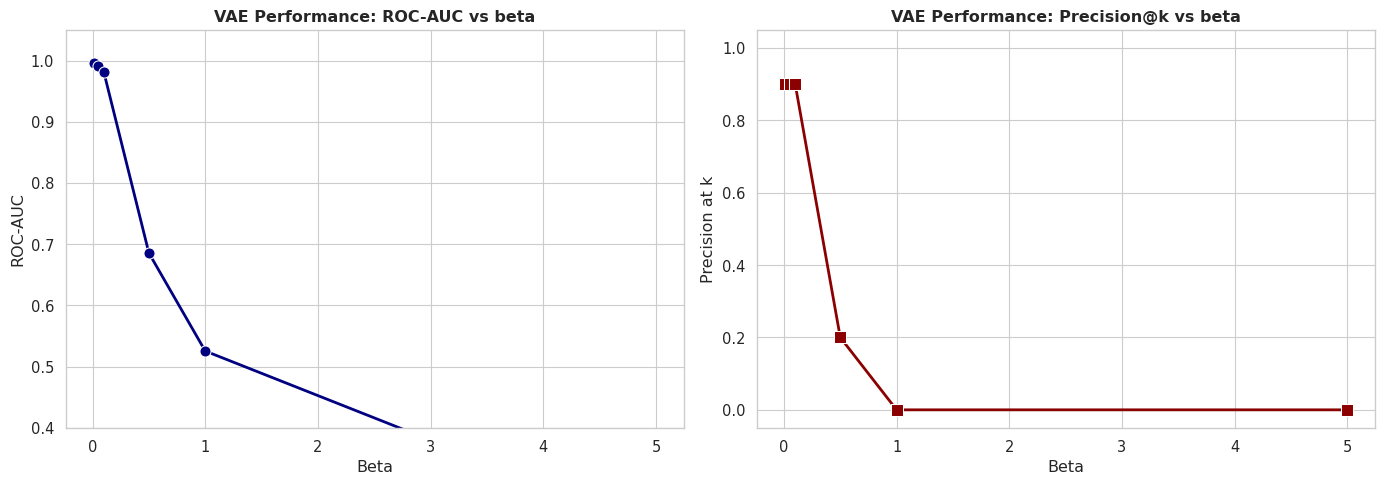

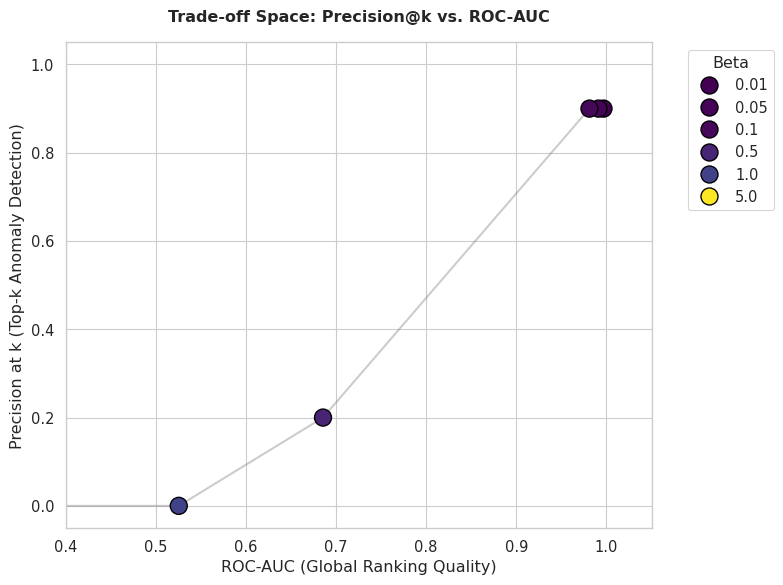

In [ ]:
# 1. Plot  1D performance met
plot_1d_experiment_results(results_df, x_col="beta")

# 2. Plot  trade-off scatter plot for global vs. top-k ranking movement
plot_roc_vs_precision(results_df, hue_col="beta")

erstelle heatmap

In [ ]:
import itertools
import pandas as pd

# 1. Define 2D parameter grid
contamination_list = [0.05, 0.10, 0.15, 0.20]
severity_list = [0.05, 0.10, 0.20, 0.30]

# 2. Define fixed parameters
fixed_params = {
    "n_features": 500,         # Fixed feature dimension
    "n_factors": 10,           # True complexity of the data
    "latent_dim": 10,          # Fixed VAE Bottleneck size
    "beta": 0.1                # Weight of the KL-Divergence penalty
}

# Generate all pairs of (contamination, severity)
param_pairs = list(itertools.product(contamination_list, severity_list))

target_q = 202312
results = []
fixed_budget_k = 10  # useless

print(f"Running {len(param_pairs)} VAE setups exploring Contamination vs. Severity...")

for i, (contam, sev) in enumerate(param_pairs):
    # Extract fixed parameters
    n_feat = fixed_params["n_features"]
    f = fixed_params["n_factors"]
    l_dim = fixed_params["latent_dim"]
    beta_val = fixed_params["beta"]
    
    print(f"--- Iteration {i+1}/{len(param_pairs)}: contamination={contam}, severity={sev} ---")
    
    # 1. Generate Full Clean Panel
    cfg = ToyConfig(n_banks=100, n_features=n_feat, n_factors=f, random_state=i)
    clean_df, value_cols = simulate_toy_finrep(cfg)
    
    # 2. Inject Anomalies  into  Target Quarter
    injection = inject_peer_anomaly(
        clean_df,
        target_quarter=target_q,
        cols=value_cols,
        row_fraction=contam,
        feature_fraction=sev,
        random_state=i
    )
    

    historical_df = clean_df[clean_df[DATE_COL] < target_q].copy()
    fm_train = compute_total_asset_ratios(historical_df, value_columns=value_cols)
    
    corrupted_df = injection["data"]
    fm_test = build_peer_ratio_matrix(corrupted_df, quarter=target_q, value_columns=value_cols)
    
    # 4. Fit Scaler  on History
    scaler = RobustIQRScaler(imputation="median")
    X_train_scaled = scaler.fit_transform(fm_train.X)
    X_test_scaled = scaler.transform(fm_test.X)
    
    # 5. Train VAE on Nominal History
    vae = VAEDetector(
        latent_dim=l_dim, 
        hidden_dim=32, 
        epochs=500,          
        beta=beta_val, 
        random_state=i
    )
    vae.fit(X_train_scaled)
    
    # 6. Score  Target Quarter
    scores = vae.score_samples(X_test_scaled)
    
    # 7. Evaluate 
    y_true = make_binary_labels(fm_test.metadata, injection["row_labels"], outlier_type="peer")
    metrics_df = evaluate_scores(y_true, scores)

    res_dict = fixed_params.copy()
    res_dict["contamination"] = contam
    res_dict["severity"] = sev
    res_dict["roc_auc"] = metrics_df["roc_auc"].iloc[0]
    res_dict["precision_at_k"] = metrics_df["precision_at_k"].iloc[0]
    res_dict["recall_at_k"] = metrics_df["recall_at_k"].iloc[0]
    
    results.append(res_dict)

results_df = pd.DataFrame(results)
print("\nVAE 2D Grid Experiment complete!")
display(results_df.head())

Running 16 VAE setups exploring Contamination vs. Severity...
--- Iteration 1/16: contamination=0.05, severity=0.05 ---
--- Iteration 2/16: contamination=0.05, severity=0.1 ---
--- Iteration 3/16: contamination=0.05, severity=0.2 ---
--- Iteration 4/16: contamination=0.05, severity=0.3 ---
--- Iteration 5/16: contamination=0.1, severity=0.05 ---
--- Iteration 6/16: contamination=0.1, severity=0.1 ---
--- Iteration 7/16: contamination=0.1, severity=0.2 ---
--- Iteration 8/16: contamination=0.1, severity=0.3 ---
--- Iteration 9/16: contamination=0.15, severity=0.05 ---
--- Iteration 10/16: contamination=0.15, severity=0.1 ---
--- Iteration 11/16: contamination=0.15, severity=0.2 ---
--- Iteration 12/16: contamination=0.15, severity=0.3 ---
--- Iteration 13/16: contamination=0.2, severity=0.05 ---
--- Iteration 14/16: contamination=0.2, severity=0.1 ---
--- Iteration 15/16: contamination=0.2, severity=0.2 ---
--- Iteration 16/16: contamination=0.2, severity=0.3 ---

VAE 2D Grid Experiment

,n_features,n_factors,latent_dim,beta,contamination,severity,roc_auc,precision_at_k,recall_at_k
0,500,10,10,0.1,0.05,0.05,0.934737,0.4,0.4
1,500,10,10,0.1,0.05,0.10,0.930526,0.6,0.6
2,500,10,10,0.1,0.05,0.20,1.000000,1.0,1.0
3,500,10,10,0.1,0.05,0.30,1.000000,1.0,1.0
4,500,10,10,0.1,0.10,0.05,0.852222,0.4,0.4


In [12]:
results_df

,n_features,n_factors,latent_dim,beta,contamination,severity,roc_auc,precision_at_k,recall_at_k
0,500,10,10,0.1,0.05,0.05,0.934737,0.400000,0.400000
1,500,10,10,0.1,0.05,0.10,0.930526,0.600000,0.600000
2,500,10,10,0.1,0.05,0.20,1.000000,1.000000,1.000000
3,500,10,10,0.1,0.05,0.30,1.000000,1.000000,1.000000
4,500,10,10,0.1,0.10,0.05,0.852222,0.400000,0.400000
5,500,10,10,0.1,0.10,0.10,0.945556,0.500000,0.500000
6,500,10,10,0.1,0.10,0.20,0.997778,0.900000,0.900000
7,500,10,10,0.1,0.10,0.30,1.000000,1.000000,1.000000
8,500,10,10,0.1,0.15,0.05,0.831373,0.466667,0.466667
9,500,10,10,0.1,0.15,0.10,0.971765,0.800000,0.800000


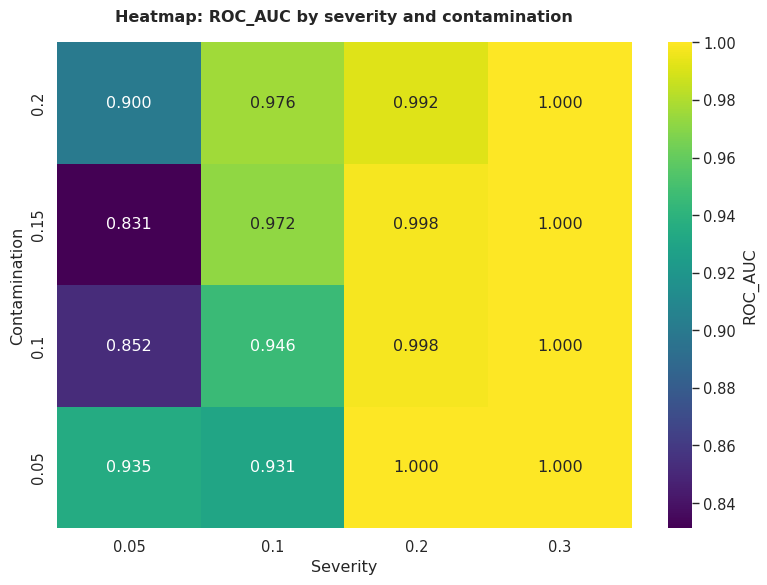

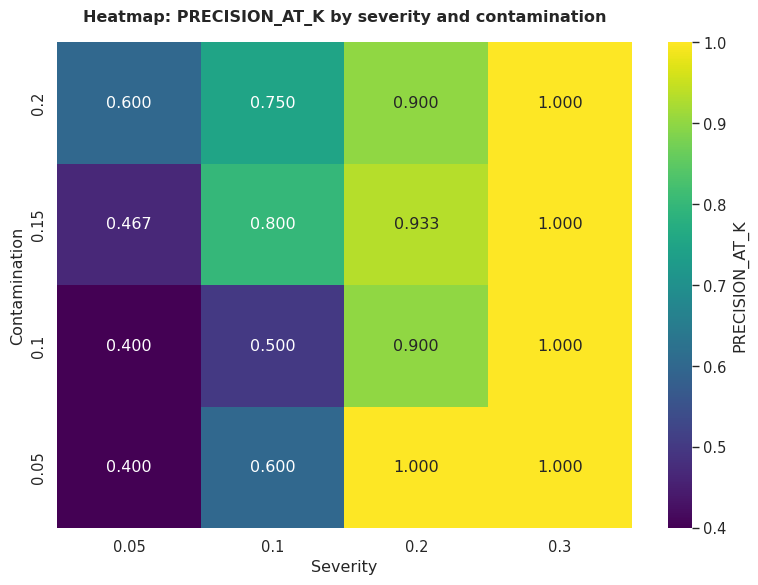

In [ ]:
# 1. Heatmap for ROC
plot_2d_heatmap(
    results_df, 
    x_col="severity", 
    y_col="contamination", 
    metric="roc_auc"
)

# 2. Heatmap for Top-k Detection 
plot_2d_heatmap(
    results_df, 
    x_col="severity", 
    y_col="contamination", 
    metric="precision_at_k"
)

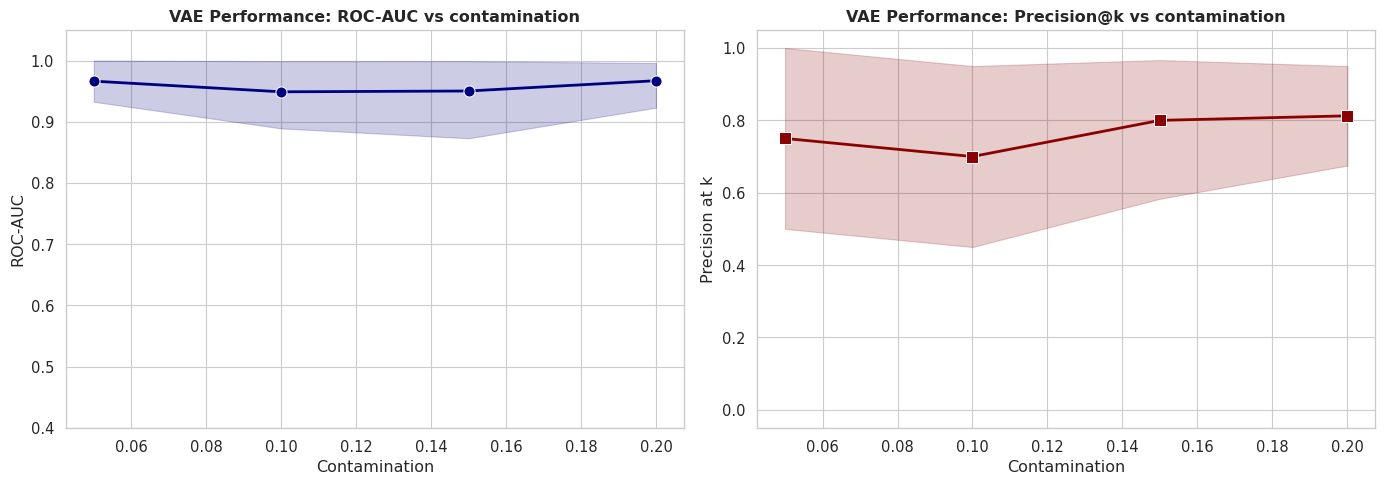

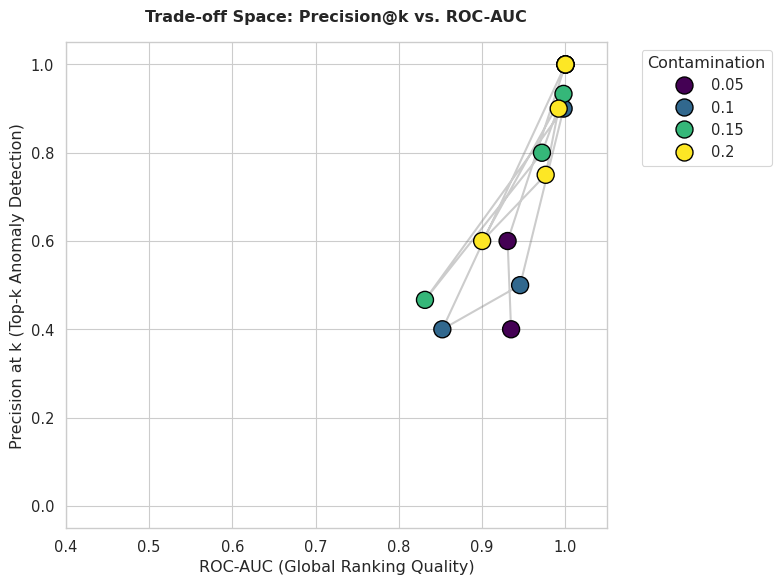

In [15]:
# 1. Plot the 1D performance metrics (ROC-AUC and Precision)
plot_1d_experiment_results(results_df, x_col="contamination")

# 2. Plot the trade-off scatter plot to see global vs. top-k ranking movement
plot_roc_vs_precision(results_df, hue_col="contamination")

latent dimension

In [ ]:
import itertools
import pandas as pd


latent_dim_list = [2, 5, 10, 15, 20, 25, 30]

# 2. Define fixed parameters
fixed_params = {
    "n_features": 500,         # Fixed feature dimension for this run
    "n_factors": 10,           # True complexity of the data
    "beta": 0.1,               # Weight of the KL-Divergence penalty
    "contamination": 0.1,      # Low vs. High contamination
    "severity": 0.1            # Mild vs. Severe structural breaks
}

target_q = 202312
results = []
fixed_budget_k = 10  #useless

print(f"Running {len(latent_dim_list)} VAE experimental setups exploring latent dimensions...")

for i, l_dim in enumerate(latent_dim_list):
    # Extract
    n_feat = fixed_params["n_features"]
    f = fixed_params["n_factors"]
    beta_val = fixed_params["beta"]
    contam = fixed_params["contamination"]
    sev = fixed_params["severity"]
    
    print(f"\n--- Starting Iteration {i+1}/{len(latent_dim_list)}: latent_dim = {l_dim} ---")
    
    # 1. Generate Full Clean Panel
    cfg = ToyConfig(n_banks=100, n_features=n_feat, n_factors=f, random_state=i)
    clean_df, value_cols = simulate_toy_finrep(cfg)
    
    # 2. Inject Anomalies  into  Target Quarter
    injection = inject_peer_anomaly(
        clean_df,
        target_quarter=target_q,
        cols=value_cols,
        row_fraction=contam,
        feature_fraction=sev,
        random_state=i
    )
    

    # History: A
    historical_df = clean_df[clean_df[DATE_COL] < target_q].copy()
    fm_train = compute_total_asset_ratios(historical_df, value_columns=value_cols)
    
    # Target:  contaminated 
    corrupted_df = injection["data"]
    fm_test = build_peer_ratio_matrix(corrupted_df, quarter=target_q, value_columns=value_cols)
    
    # 4. Fit Scaler
    scaler = RobustIQRScaler(imputation="median")
    X_train_scaled = scaler.fit_transform(fm_train.X)
    X_test_scaled = scaler.transform(fm_test.X)
    
    # 5. Train VAE on Nominal History
    vae = VAEDetector(
        latent_dim=l_dim, 
        hidden_dim=32, 
        epochs=500,          
        beta=beta_val, 
        random_state=i
    )
    vae.fit(X_train_scaled)
    
    # 6. Score  Target Quarter
    scores = vae.score_samples(X_test_scaled)
    
    # 7. Evaluate 
    y_true = make_binary_labels(fm_test.metadata, injection["row_labels"], outlier_type="peer")
    metrics_df = evaluate_scores(y_true, scores)
    
    res_dict = fixed_params.copy()
    res_dict["latent_dim"] = l_dim
    res_dict["roc_auc"] = metrics_df["roc_auc"].iloc[0]
    res_dict["precision_at_k"] = metrics_df["precision_at_k"].iloc[0]
    res_dict["recall_at_k"] = metrics_df["recall_at_k"].iloc[0]
    
    results.append(res_dict)

results_df = pd.DataFrame(results)
print("\nVAE Latent Dimension Experiment complete!")
display(results_df)

Running 7 VAE experimental setups exploring latent dimensions...

--- Starting Iteration 1/7: latent_dim = 2 ---

--- Starting Iteration 2/7: latent_dim = 5 ---

--- Starting Iteration 3/7: latent_dim = 10 ---

--- Starting Iteration 4/7: latent_dim = 15 ---

--- Starting Iteration 5/7: latent_dim = 20 ---

--- Starting Iteration 6/7: latent_dim = 25 ---

--- Starting Iteration 7/7: latent_dim = 30 ---

VAE Latent Dimension Experiment complete!


,n_features,n_factors,beta,contamination,severity,latent_dim,roc_auc,precision_at_k,recall_at_k
0,500,10,0.1,0.1,0.1,2,0.621111,0.1,0.1
1,500,10,0.1,0.1,0.1,5,0.764444,0.2,0.2
2,500,10,0.1,0.1,0.1,10,0.981111,0.9,0.9
3,500,10,0.1,0.1,0.1,15,0.985556,0.8,0.8
4,500,10,0.1,0.1,0.1,20,0.986667,0.7,0.7
5,500,10,0.1,0.1,0.1,25,0.970000,0.7,0.7
6,500,10,0.1,0.1,0.1,30,0.986667,0.9,0.9


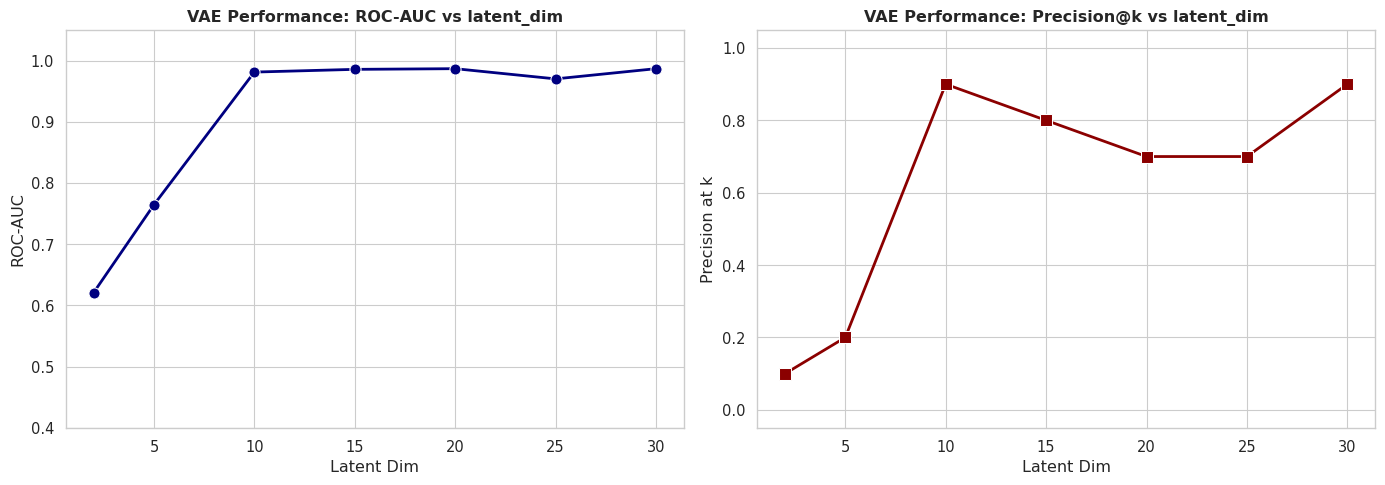

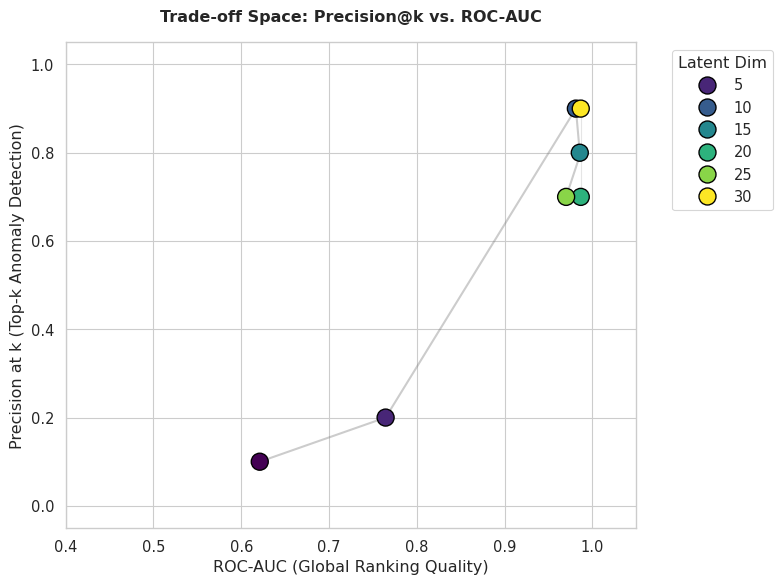

In [ ]:
# 1. P(ROC-AUC and Precision)
plot_1d_experiment_results(results_df, x_col="latent_dim")

# 2.global vs. top-k ranking
plot_roc_vs_precision(results_df, hue_col="latent_dim")